In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from fismi import ismiReplication as fismi
from fismi import utils
from fismi import figures

In [2]:
# Import data
niv = '4'

# HICP All Items
colHicp = "INX"

# Unchained other items 
dfICP = pd.read_parquet(f"input/USItemsLvl{niv}.parquet")
dfW = pd.read_parquet(f"input/USnormedWeightsLvl{niv}.parquet") 

In [3]:
# We compute headline inflation (PCE variation over a 12-month period)
headline = (np.log(dfICP["Personal consumption expenditures"]).diff(12)[1:]*100)  # Inflation headline annuelle glissante

# We compute monthly inflation rates
dfInflation = (np.log(dfICP).diff(1)[1:]*100)
InflTot = dfInflation["Personal consumption expenditures"].to_frame()           # To replicate Figure A1
dfInflation = dfInflation.drop("Personal consumption expenditures",axis=1)

In [4]:
# Drop series
colToDrop = ["Internet access (72)","Video and audio streaming and rental"]
dfInflation = dfInflation.loc[:, ~dfInflation.columns.isin(colToDrop)]
dfW = dfW.loc[:, ~dfW.columns.isin(colToDrop)]

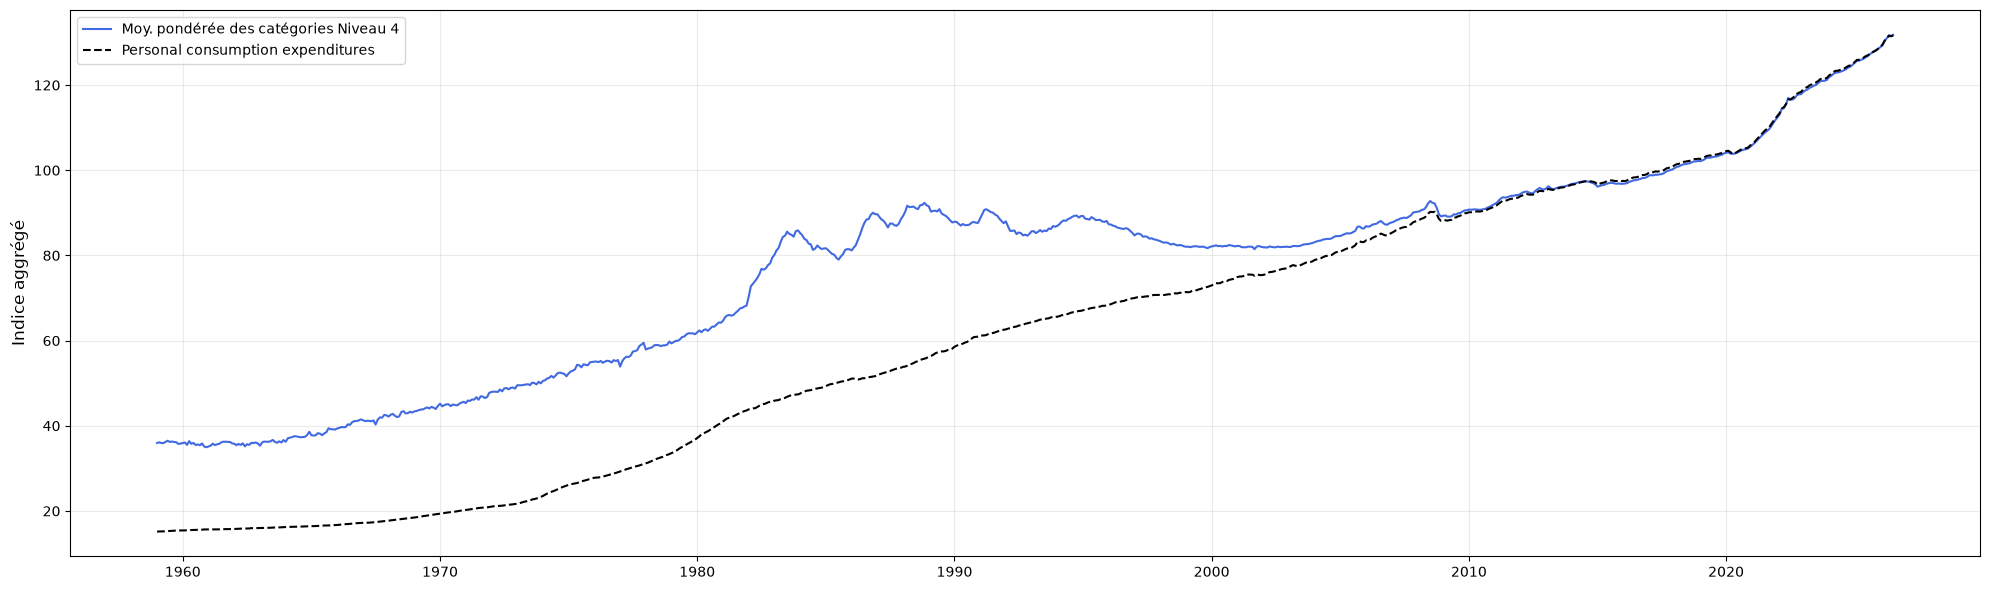

In [5]:
# Graphique 1
figures.plotAggregatedIndex(dfW,dfICP,"Personal consumption expenditures",niv)

In [6]:
# Call estimates
df_shocks, aCoef, rhoCoef = fismi.twoStepsAr(dfInflation, rolling_window=120)
posItems, negItems, posIsmi, negIsmi, ismIndex = fismi.replicateIsmi(dfInflation, df_shocks, dfW)

# Merge
ismIndex = ismIndex.to_frame().merge(
    InflTot,
    how="left",
    left_index=True,
    right_index=True)

Step 1 : Estimate 129 AR(1) on a 120 month rolling window...
Step 2 : Compute inflation momentum and aggregate...
Done


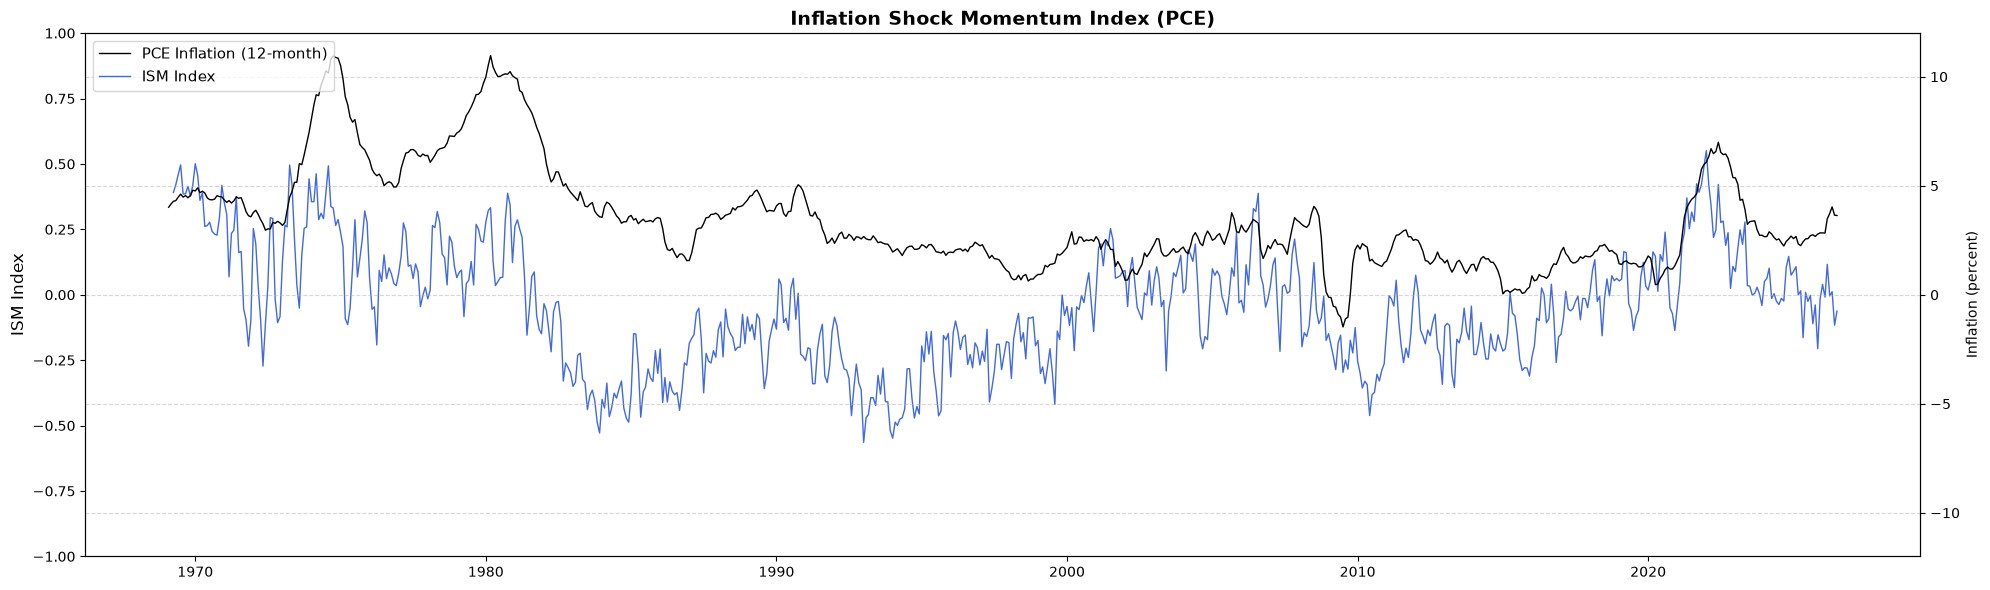

In [7]:
# Figure 2
figures.ismiVersusIndex(ismIndex, headline[120:], index="PCE")

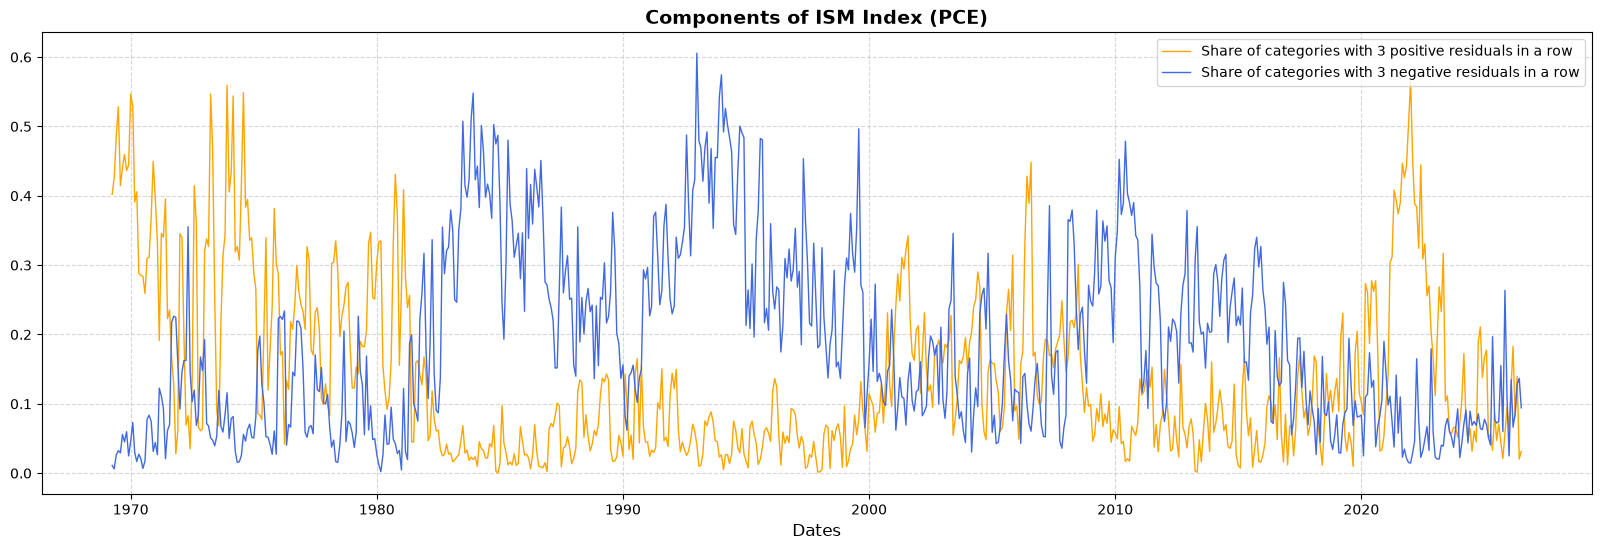

In [8]:
# Figure 3 
figures.posVersusNeg(posIsmi,negIsmi,index="PCE")

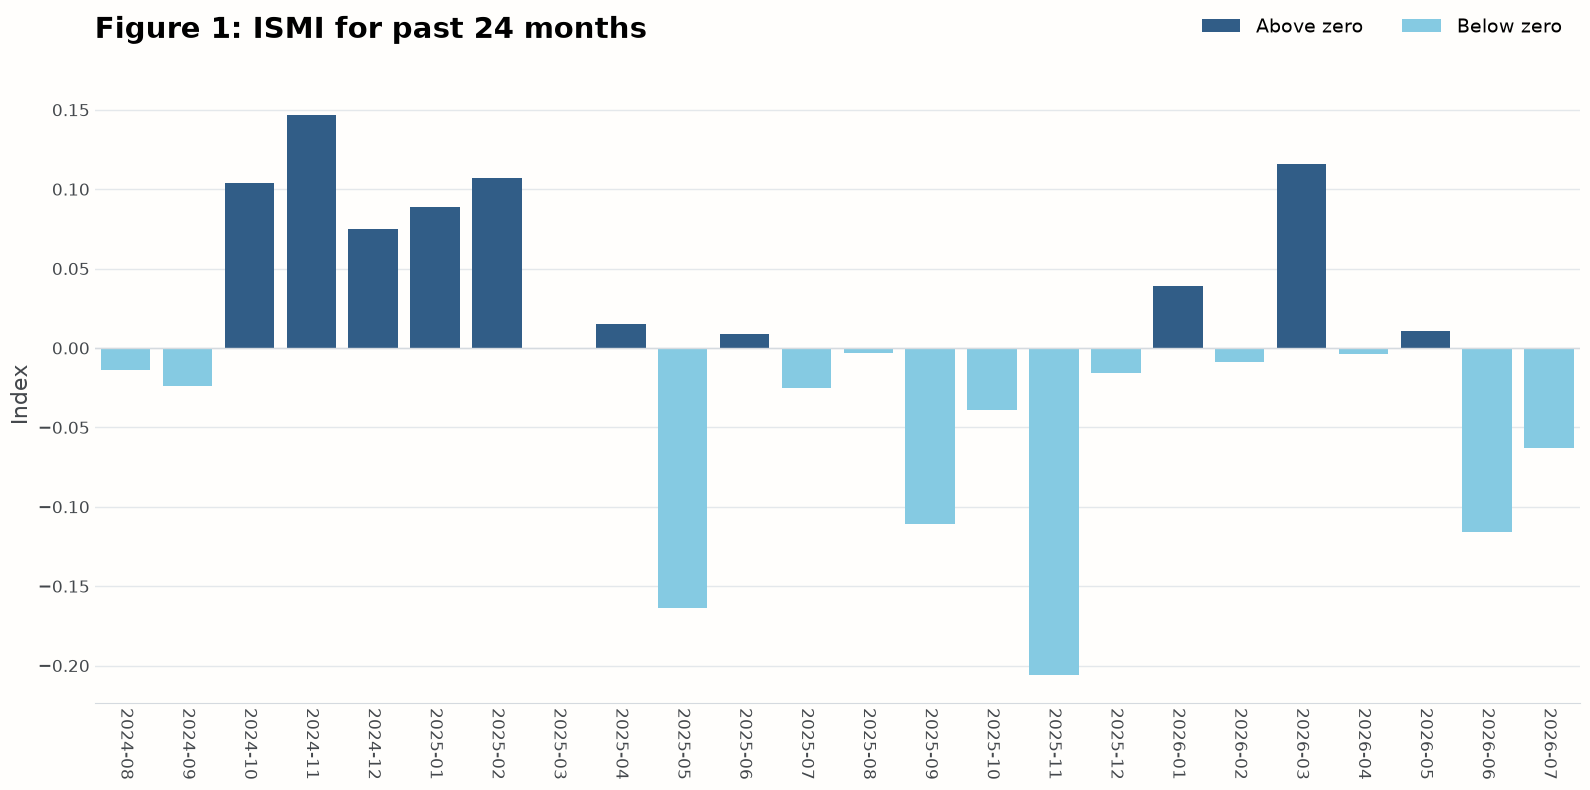

In [9]:
# Fed Chart Type
figures.FedStyleChart(ismIndex)

In [10]:
# Compare with Shapiro
ShapiroResults = pd.read_excel("ismi_data.xlsx", "k3_AR1")
# Convert the dates
ShapiroResults["date"] = pd.to_datetime(ShapiroResults["date"])
ShapiroResults = ShapiroResults.set_index("date")

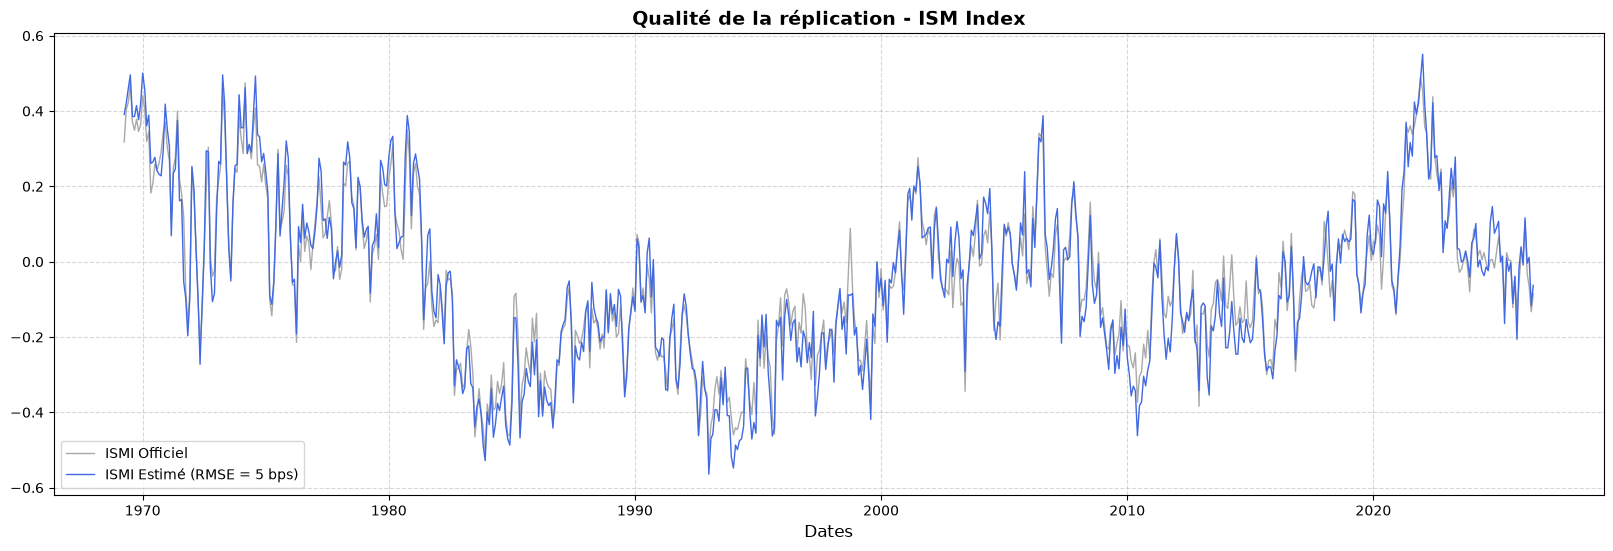

In [11]:
# Compare headline series 
AllSeries = ismIndex.merge(
    ShapiroResults["ismi_headline_ar1_k3"],
    how="left",
    right_index=True,
    left_index=True
)

# Compute RMSE
RMSE = utils.rmse(AllSeries["ismi_headline_ar1_k3"].values, AllSeries["ISMIndex"].values)

fig, ax = plt.subplots(figsize=(20, 6))
x_axis = AllSeries.index
ax.plot(
    x_axis,
    AllSeries["ismi_headline_ar1_k3"].values,
    color="darkgrey",
    label="ISMI Officiel",
    linewidth=1,
)

ax.plot(
    x_axis,
    AllSeries["ISMIndex"].values,
    label=f"ISMI Estimé (RMSE = {RMSE*100:.0f} bps)",
    color="royalblue",
    linewidth=1,
)

ax.legend()
ax.set_xlabel("Dates", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

plt.title("Qualité de la réplication - ISM Index", fontsize=14, fontweight="bold")
plt.show()


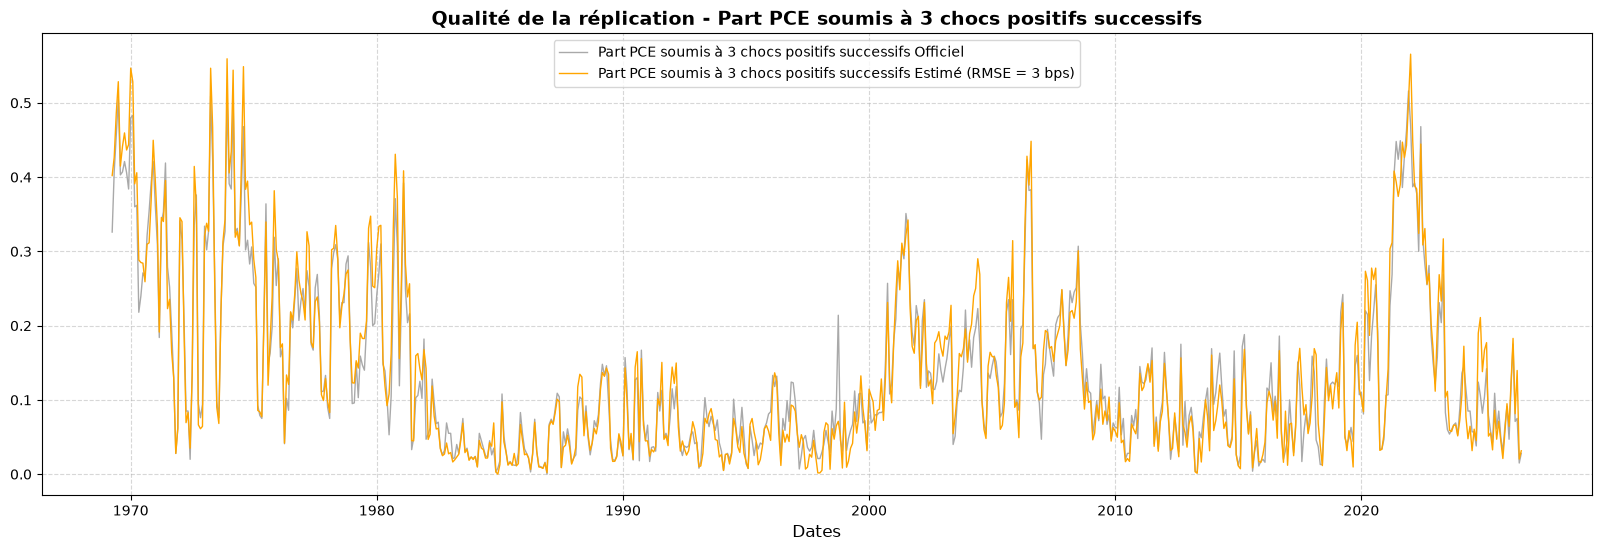

In [12]:
# Compare headline positive series 
AllSeries = posIsmi.to_frame().merge(
    ShapiroResults["ismi_headline_positive_ar1_k3"],
    how="left",
    right_index=True,
    left_index=True
)

# Compute RMSE
RMSE = utils.rmse(AllSeries["ismi_headline_positive_ar1_k3"].values, AllSeries["ISMI+"].values)

fig, ax = plt.subplots(figsize=(20, 6))
x_axis = AllSeries.index
ax.plot(
    x_axis,
    AllSeries["ismi_headline_positive_ar1_k3"].values,
    color="darkgrey",
    label="Part PCE soumis à 3 chocs positifs successifs Officiel",
    linewidth=1,
)

ax.plot(
    x_axis,
    AllSeries["ISMI+"].values,
    label=f"Part PCE soumis à 3 chocs positifs successifs Estimé (RMSE = {RMSE*100:.0f} bps)",
    color="orange",
    linewidth=1,
)

ax.legend()
ax.set_xlabel("Dates", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

plt.title("Qualité de la réplication - Part PCE soumis à 3 chocs positifs successifs", fontsize=14, fontweight="bold")
plt.show()

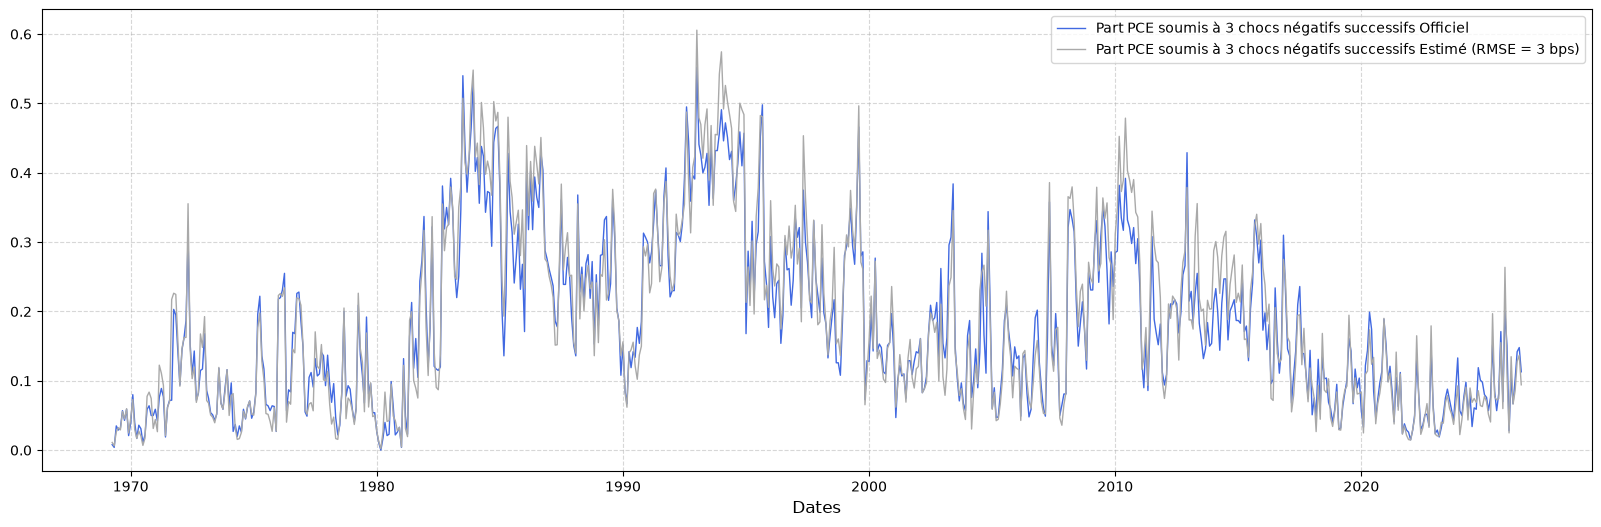

In [13]:
# Compare headline negative series 
AllSeries = negIsmi.to_frame().merge(
    ShapiroResults["ismi_headline_negative_ar1_k3"],
    how="left",
    right_index=True,
    left_index=True
)

# Compute RMSE
RMSE = utils.rmse(AllSeries["ismi_headline_negative_ar1_k3"].values, AllSeries["ISMI-"].values)

fig, ax = plt.subplots(figsize=(20, 6))
x_axis = AllSeries.index
ax.plot(
    x_axis,
    AllSeries["ismi_headline_negative_ar1_k3"].values,
    color="royalblue",
    label="Part PCE soumis à 3 chocs négatifs successifs Officiel",
    linewidth=1,
)

ax.plot(
    x_axis,
    AllSeries["ISMI-"].values,
    label=f"Part PCE soumis à 3 chocs négatifs successifs Estimé (RMSE = {RMSE*100:.0f} bps)",
    color="darkgrey",
    linewidth=1,
)

ax.legend()
ax.set_xlabel("Dates", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)

In [14]:
# Réplication Figure A1
df_shocks, aCoef, rhoCoef = fismi.twoStepsAr(InflTot)

# Drop NaN and merge
PCE = InflTot.copy()
PCE["Shocks"] = df_shocks.values
PCE["A"] = aCoef.values
PCE["Rho"] = rhoCoef.values
PCE = PCE.dropna()

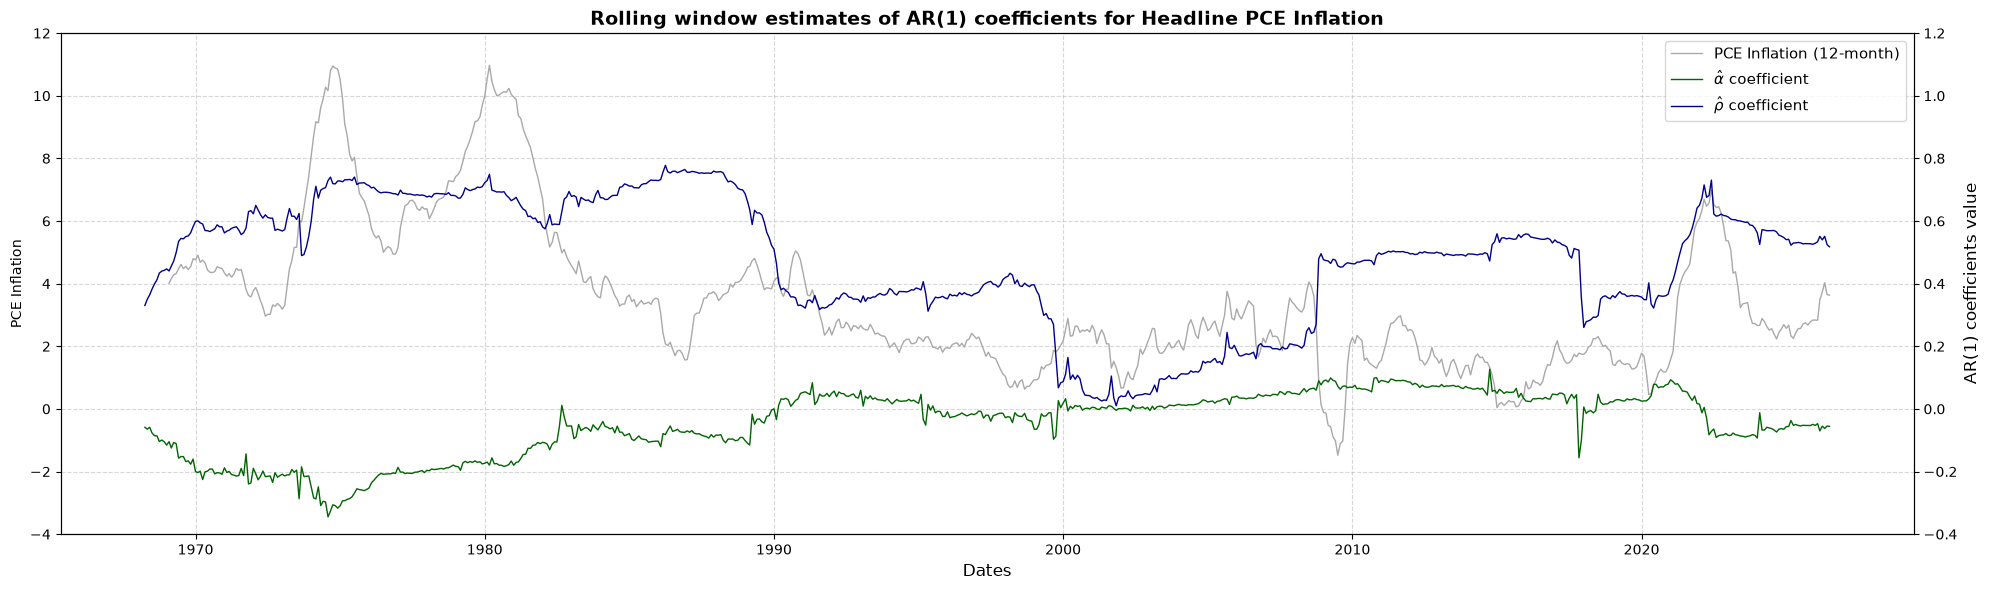

In [15]:
# Appendix A1
figures.figA1Paper(headline.iloc[120:], PCE,"PCE")